# Machine Learning con Big Data en Databricks Free Edition
# Versión mejorada:
# - Logistic Regression
# - Random Forest
# - comparación automática
# - gráficos simples

In [0]:
from pyspark.sql.types import *
from pyspark.sql.functions import col, trim, when

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

import mlflow
import mlflow.spark

import pandas as pd
import matplotlib.pyplot as plt

In [0]:
schema = StructType([
    StructField("age", IntegerType(), True),
    StructField("workclass", StringType(), True),
    StructField("fnlwgt", IntegerType(), True),
    StructField("education", StringType(), True),
    StructField("education_num", IntegerType(), True),
    StructField("marital_status", StringType(), True),
    StructField("occupation", StringType(), True),
    StructField("relationship", StringType(), True),
    StructField("race", StringType(), True),
    StructField("sex", StringType(), True),
    StructField("capital_gain", IntegerType(), True),
    StructField("capital_loss", IntegerType(), True),
    StructField("hours_per_week", IntegerType(), True),
    StructField("native_country", StringType(), True),
    StructField("income", StringType(), True)
])

# df = spark.read.csv(
#     "/databricks-datasets/adult/adult.data",
#     schema=schema,
#     header=False
# )

df = (
    spark.read
    .option("header", "false")
    .option("sep", ",")
    .option("ignoreLeadingWhiteSpace", "true")
    .option("ignoreTrailingWhiteSpace", "true")
    .schema(schema)
    .csv("/databricks-datasets/adult/adult.data")
)

display(df.limit(50))
print("Cantidad de filas:", df.count())

age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


Cantidad de filas: 32561


In [0]:
string_cols = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country", "income"
]

for c in string_cols:
    df = df.withColumn(c, trim(col(c)))
print("Cantidad de filas después de limpieza 1:", df.count())
for c in string_cols:
    if c != "income":
        df = df.withColumn(c, when(col(c) == "?", None).otherwise(col(c)))
print("Cantidad de filas después de limpieza 2:", df.count())
df = df.dropna()

print("Cantidad de filas después de limpieza:", df.count())
display(df.limit(10))

Cantidad de filas después de limpieza 1: 32561
Cantidad de filas después de limpieza 2: 32561
Cantidad de filas después de limpieza: 30162


age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [0]:
display(df.groupBy("income").count())
display(df.groupBy("sex").count())
display(df.select("age", "hours_per_week", "capital_gain", "capital_loss"))

income,count
<=50K,22654
>50K,7508


sex,count
Male,20380
Female,9782


age,hours_per_week,capital_gain,capital_loss
39,40,2174,0
50,13,0,0
38,40,0,0
53,40,0,0
28,40,0,0
37,40,0,0
49,16,0,0
52,45,0,0
31,50,14084,0
42,40,5178,0


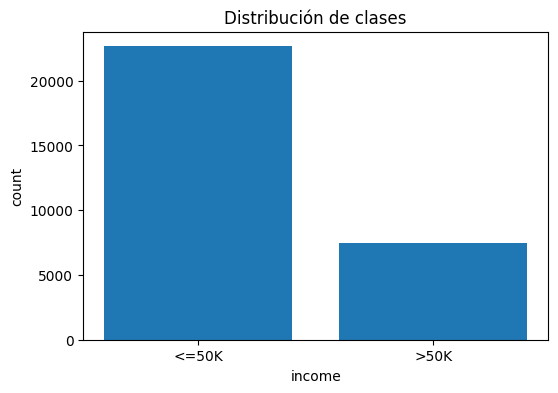

In [0]:
class_dist_pd = df.groupBy("income").count().toPandas()

plt.figure(figsize=(6,4))
plt.bar(class_dist_pd["income"], class_dist_pd["count"])
plt.title("Distribución de clases")
plt.xlabel("income")
plt.ylabel("count")
plt.show()

In [0]:
categorical_cols = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]

numeric_cols = [
    "age", "fnlwgt", "education_num", "capital_gain",
    "capital_loss", "hours_per_week"
]

In [0]:
label_indexer = StringIndexer(inputCol="income", outputCol="label")

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    for c in categorical_cols
]

assembler_inputs = numeric_cols + [f"{c}_ohe" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features"
)

In [0]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print("Train:", train_df.count())
print("Test:", test_df.count())

Train: 24337
Test: 5825


In [0]:
# def train_evaluate_log(model_name, classifier, extra_params=None):
#     pipeline = Pipeline(
#         stages=[label_indexer] + indexers + encoders + [assembler, classifier]
#     )

#     with mlflow.start_run(run_name=model_name):
#         fitted_model = pipeline.fit(train_df)
#         predictions = fitted_model.transform(test_df)

#         binary_eval = BinaryClassificationEvaluator(
#             labelCol="label",
#             rawPredictionCol="rawPrediction",
#             metricName="areaUnderROC"
#         )

#         acc_eval = MulticlassClassificationEvaluator(
#             labelCol="label",
#             predictionCol="prediction",
#             metricName="accuracy"
#         )

#         auc = binary_eval.evaluate(predictions)
#         accuracy = acc_eval.evaluate(predictions)

#         mlflow.log_param("model_name", model_name)

#         if extra_params:
#             for k, v in extra_params.items():
#                 mlflow.log_param(k, v)

#         mlflow.log_metric("auc", auc)
#         mlflow.log_metric("accuracy", accuracy)

#         mlflow.spark.log_model(fitted_model, "model")

#         result = {
#             "model_name": model_name,
#             "accuracy": accuracy,
#             "auc": auc
#         }

#         if extra_params:
#             result.update(extra_params)

#         return fitted_model, predictions, result

In [0]:
import gc

# Ajuste para Spark Connect / Free Edition:
# el preprocesamiento se ajusta una sola vez y luego se reutiliza
# para evitar acumular PipelineModels grandes en el cache de ML.
preprocessing_pipeline = Pipeline(
    stages=[label_indexer] + indexers + encoders + [assembler]
)

preprocessing_model = preprocessing_pipeline.fit(train_df)

prepared_cols = [
    "age", "education", "occupation", "hours_per_week",
    "income", "label", "features"
]

train_prepared_df = preprocessing_model.transform(train_df).select(*prepared_cols)
test_prepared_df = preprocessing_model.transform(test_df).select(*prepared_cols)

del preprocessing_model
del preprocessing_pipeline
gc.collect()

print("Prepared train:", train_prepared_df.count())
print("Prepared test:", test_prepared_df.count())

In [0]:
%sql
CREATE VOLUME IF NOT EXISTS big_data_ii_2025.spark_examples.mlflow_tmp;

In [0]:
# from pyspark.ml import Pipeline
# from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
# import mlflow
# import mlflow.spark

# UC_TMP_DIR = "/Volumes/big_data_ii_2025/spark_examples/mlflow_tmp/mlflow_spark_tmp"

# def train_evaluate_log(model_name, classifier, extra_params=None, dfs_tmpdir=UC_TMP_DIR):
#     pipeline = Pipeline(
#         stages=[label_indexer] + indexers + encoders + [assembler, classifier]
#     )

#     with mlflow.start_run(run_name=model_name):
#         fitted_model = pipeline.fit(train_df)
#         predictions = fitted_model.transform(test_df)

#         binary_eval = BinaryClassificationEvaluator(
#             labelCol="label",
#             rawPredictionCol="rawPrediction",
#             metricName="areaUnderROC"
#         )

#         acc_eval = MulticlassClassificationEvaluator(
#             labelCol="label",
#             predictionCol="prediction",
#             metricName="accuracy"
#         )

#         auc = binary_eval.evaluate(predictions)
#         accuracy = acc_eval.evaluate(predictions)

#         mlflow.log_param("model_name", model_name)

#         if extra_params:
#             for k, v in extra_params.items():
#                 mlflow.log_param(k, v)

#         mlflow.log_metric("auc", auc)
#         mlflow.log_metric("accuracy", accuracy)

#         mlflow.spark.log_model(
#             spark_model=fitted_model,
#             artifact_path="model",
#             dfs_tmpdir=dfs_tmpdir
#         )

#         result = {
#             "model_name": model_name,
#             "accuracy": accuracy,
#             "auc": auc
#         }

#         if extra_params:
#             result.update(extra_params)

#         return fitted_model, predictions, result

In [0]:
import gc
import mlflow
import mlflow.spark
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

# Keep this only if you still want to log Spark models to MLflow
UC_TMP_DIR = "/Volumes/<your_catalog>/default/mlflow_tmp/mlflow_spark_tmp"
MAX_TRAIN_ROWS_FREE_EDITION = 12000

def cleanup_ml_cache_vars():
    # Remove common model variables from the notebook session
    for name in [
        "lr_model", "rf_model", "model", "model2", "fitted_model",
        "pipeline_model", "best_model", "lr_predictions", "rf_predictions",
        "preprocessing_model", "preprocessing_pipeline"
    ]:
        if name in globals():
            del globals()[name]
    gc.collect()

def build_training_subset(df, max_rows=MAX_TRAIN_ROWS_FREE_EDITION, seed=42):
    row_count = df.count()
    if row_count <= max_rows:
        return df, row_count, 1.0

    fraction = max_rows / row_count
    labels = [row["label"] for row in df.select("label").distinct().collect()]
    fractions = {label: fraction for label in labels}

    sampled_df = df.sampleBy("label", fractions=fractions, seed=seed)
    sampled_count = sampled_df.count()

    return sampled_df, sampled_count, fraction

def train_evaluate_log(
    model_name,
    classifier,
    extra_params=None,
    log_spark_model=False,
    dfs_tmpdir=UC_TMP_DIR
):
    # Best effort cleanup before fitting a new model
    cleanup_ml_cache_vars()

    train_model_df, sampled_rows, sampled_fraction = build_training_subset(train_prepared_df)

    with mlflow.start_run(run_name=model_name):
        fitted_model = classifier.fit(train_model_df)
        predictions = fitted_model.transform(test_prepared_df)

        binary_eval = BinaryClassificationEvaluator(
            labelCol="label",
            rawPredictionCol="rawPrediction",
            metricName="areaUnderROC"
        )

        acc_eval = MulticlassClassificationEvaluator(
            labelCol="label",
            predictionCol="prediction",
            metricName="accuracy"
        )

        auc = binary_eval.evaluate(predictions)
        accuracy = acc_eval.evaluate(predictions)

        mlflow.log_param("model_name", model_name)
        if extra_params:
            for k, v in extra_params.items():
                mlflow.log_param(k, v)

        mlflow.log_metric("auc", auc)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("train_rows_used", sampled_rows)
        mlflow.log_metric("train_fraction_used", sampled_fraction)

        prediction_sample_pd = (
            predictions
            .select(
                "age",
                "education",
                "occupation",
                "hours_per_week",
                "income",
                "prediction",
                vector_to_array("probability")[0].alias("probability_0"),
                vector_to_array("probability")[1].alias("probability_1")
            )
            .limit(20)
            .toPandas()
        )

        confusion_pd = (
            predictions
            .groupBy("label", "prediction")
            .count()
            .orderBy("label", "prediction")
            .toPandas()
        )

        # Optional. For Free Edition class demos, I recommend False.
        if log_spark_model:
            mlflow.spark.log_model(
                spark_model=fitted_model,
                artifact_path="model",
                dfs_tmpdir=dfs_tmpdir
            )

        result = {
            "model_name": model_name,
            "accuracy": accuracy,
            "auc": auc,
            "train_rows_used": sampled_rows
        }
        if extra_params:
            result.update(extra_params)

        # Explicit cleanup
        del train_model_df
        del predictions
        del fitted_model
        gc.collect()

        return prediction_sample_pd, confusion_pd, result

In [0]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.0
)

lr_prediction_sample, lr_confusion, lr_result = train_evaluate_log(
    model_name="LogisticRegression",
    classifier=lr,
    extra_params={
        "maxIter": 20,
        "regParam": 0.0
    },
    log_spark_model=False   # Para evitar pegar con limites en el Free Edition
)

print(lr_result)
display(lr_prediction_sample)
display(lr_confusion)

{"ts": "2026-03-29 20:44:11.997", "level": "ERROR", "logger": "pyspark.sql.connect.logging", "msg": "GRPC Error received", "context": {}, "exception": {"class": "_MultiThreadedRendezvous", "msg": "<_MultiThreadedRendezvous of RPC that terminated with:\n\tstatus = StatusCode.INTERNAL\n\tdetails = \"[CONNECT_ML.ML_CACHE_SIZE_OVERFLOW_EXCEPTION] Generic Spark Connect ML error. The model cache size in current session is about to exceed\n1073741824 bytes.\nPlease delete existing cached model by executing 'del model' in python client before fitting new model or loading new model SQLSTATE: XX000\"\n\tdebug_error_string = \"UNKNOWN:Error received from peer  {created_time:\"2026-03-29T20:44:11.996062068+00:00\", grpc_status:13, grpc_message:\"[CONNECT_ML.ML_CACHE_SIZE_OVERFLOW_EXCEPTION] Generic Spark Connect ML error. The model cache size in current session is about to exceed\\n1073741824 bytes.\\nPlease delete existing cached model by executing \\'del model\\' in python client before fitting 

---------------------------------------------------------------------------
SparkException                            Traceback (most recent call last)
File <command-5855626978231799>, line 8
      1 lr = LogisticRegression(
      2     featuresCol="features",
      3     labelCol="label",
      4     maxIter=20,
      5     regParam=0.0
      6 )
----> 8 lr_prediction_sample, lr_confusion, lr_result = train_evaluate_log(
      9     model_name="LogisticRegression",
     10     classifier=lr,
     11     extra_params={
     12         "maxIter": 20,
     13         "regParam": 0.0
     14     },
     15     log_spark_model=False   # Para evitar pegar con limites en el Free Edition
     16 )
     18 print(lr_result)
     19 display(lr_prediction_sample)

File <command-5855626978231798>, line 37, in train_evaluate_log(model_name, classifier, extra_params, log_spark_model, dfs_tmpdir)
     32 pipeline = Pipeline(
     33     stages=[label_indexer] + indexers + encoders + [assembler, class

In [0]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=20,
    maxDepth=6,
    seed=42
)

rf_prediction_sample, rf_confusion, rf_result = train_evaluate_log(
    model_name="RandomForest",
    classifier=rf,
    extra_params={
        "numTrees": 20,
        "maxDepth": 6
    }
)

print(rf_result)

In [0]:
results_pd = pd.DataFrame([lr_result, rf_result])
results_pd = results_pd[["model_name", "accuracy", "auc"] + [c for c in results_pd.columns if c not in ["model_name", "accuracy", "auc"]]]

display(spark.createDataFrame(results_pd))

In [0]:
plt.figure(figsize=(6,4))
plt.bar(results_pd["model_name"], results_pd["accuracy"])
plt.title("Comparación de Accuracy")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.show()

In [0]:
plt.figure(figsize=(6,4))
plt.bar(results_pd["model_name"], results_pd["auc"])
plt.title("Comparación de AUC")
plt.xlabel("Modelo")
plt.ylabel("AUC")
plt.show()

In [0]:
display(
    spark.createDataFrame(lr_prediction_sample)
)

In [0]:
display(
    spark.createDataFrame(rf_prediction_sample)
)

In [0]:
display(
    spark.createDataFrame(lr_confusion)
)

In [0]:
display(
    spark.createDataFrame(rf_confusion)
)

In [0]:
lr_conf_pd = lr_confusion.copy()
lr_pivot = lr_conf_pd.pivot(index="label", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(5,4))
plt.imshow(lr_pivot, aspect="auto")
plt.title("Matriz de confusión - Logistic Regression")
plt.xlabel("prediction")
plt.ylabel("label")
plt.xticks(range(len(lr_pivot.columns)), lr_pivot.columns)
plt.yticks(range(len(lr_pivot.index)), lr_pivot.index)
plt.colorbar()
plt.show()

In [0]:
rf_conf_pd = rf_confusion.copy()
rf_pivot = rf_conf_pd.pivot(index="label", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(5,4))
plt.imshow(rf_pivot, aspect="auto")
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("prediction")
plt.ylabel("label")
plt.xticks(range(len(rf_pivot.columns)), rf_pivot.columns)
plt.yticks(range(len(rf_pivot.index)), rf_pivot.index)
plt.colorbar()
plt.show()

In [0]:
best_by_accuracy = results_pd.sort_values("accuracy", ascending=False).iloc[0]
best_by_auc = results_pd.sort_values("auc", ascending=False).iloc[0]

print("Mejor modelo por accuracy:", best_by_accuracy["model_name"], "-", best_by_accuracy["accuracy"])
print("Mejor modelo por AUC:", best_by_auc["model_name"], "-", best_by_auc["auc"])

In [0]:
print("Notebook finalizado.")
print("Revisa la interfaz de MLflow del notebook para ver las corridas registradas.")